# 신경망 학습

- 학습: 훈련 데이터로부터 가중치 매개변수의 최적값을 자동으로 획득하는 것을 뜻함   
- 손실 함수: 신경망이 학습할 수 있도록 해주는 지표

이 손실 함수의 결괏값을 가장 작게 만드는 가중치 매개변수를 찾는 것이 목표   
- 이번 장에서는 손실 함수의 값을 가급적 작게 만드는 기법으로, 함수의 기울기를 활용하는 방법인 경사법을 사용

## 데이터에서 학습한다

신경망의 특징은 데이터를 보고 학습할 수 있다는 점   
- 데이터에서 학습한다는 것은 가중치 매개변수의 값을 데이터를 보고 자동으로 결정한다는 뜻

만약 모든 매개변수를 수작업으로 결정해야 한다고 생각해보면
- 2장의 퍼셉트론 예에서는 진리표를 보면서 사람이 수작업으로 매개변수 값을 설정함, 하지만 이때는 매개변수가 겨우 3개였음
- 실제 신경망에서는 매개변수가 수천에서 수만개 - 나아가 층을 깊게 한 딥러닝 정도 되면 수억에 이를 수도 있음

이쯤되면 매개변수를 수작업으로 정한다는 것은 아예 불가능   

이번 장에서는 신경망 학습(데이터로부터 매개변수의 값을 정하는 방법)에 대해서 설명하고 파이썬으로 MNIST 데이터셋의 손글씨 숫자를 학습하는 코드를 구현해봄

> 2장의 퍼셉트론도 직선으로 분리할 수 있는(선형 분리 기능) 문제라면 데이터로부터 자동으로 학습할 수 있음   
> 선형 분리 가능 문제는 유한 번의 학습을 통해 풀 수 있다는 사실이 **퍼셉트론 수렴 정리**로 증명됨   
> 하지만 비선형 분리 문제는 자동으로 학습할 수 없음

### 데이터 주도 학습

기계학습은 데이터가 생명   
데이터에서 답을 찾고 데이터에서 패턴을 발견하고 데이터로 이야기를 만드는 것이 기계학습   
데이터가 없으면 아무것도 시작되지 않음   
-> 그래서 기계학습의 중심에는 데이터가 존재함
- 이처럼 데이터가 이끄는 접근 방식 덕에 사람 중심 접근에서 벗어날 수 있음


보통 어떤 문제를 해결하려 들 때, 특히 어쩐 패턴을 찾아내야 할 떄는 사람이 이것저것 생각하고 답을 찾는 것이 일반적
- "이 문제는 아무래도 이런 규칙성이 있는 것 같아", "아니, 근본 원인은 다른 데 있을지도 몰라"
- 와 같이 사람의 경험과 직관을 단서로 시행착오를 거듭하며 일을 진행함

반면 기계학습에서는 사람의 개입을 최소화하고 수집한 데이터로부터 패턴을 찾으려 시도함   
게다가 신경망과 딥러닝은 기존 기계학습에서 사용하던 방법보다 사람의 개입을 더욱 배제할 수 있게 해주는 중요한 특성을 지님


구체적인 예시로
- 이미지에서 '5'라는 숫자를 인식하는 프로그램을 구현     
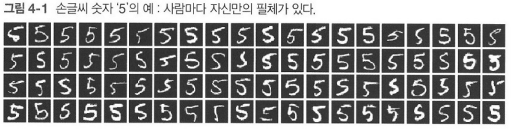   
- 그림과 같은 자유분방한 손글씨 이미지를 보고 5인지 아닌지를 알아보는 프로그램을 구현하는 것이 목표
- 비교적 단순해 보이지만 '5'를 제대로 분류하는 프로그램을 직접 고안해 설계하기한 의외로 어려운 문제임
- 사람이라면 어렵지 않게 인식하지만, 그 안에 숨은 규칙성을 명확한 로직으로 풀기가 어려움
- 사실 그림을 잘 보면, 사람마다 버릇이 달라 '5'를 특정짓는 규칙을 찾기도 쉽지 않고 시간도 오래 걸릴 것 같다는 느낌이 듦

'5'를 인식하는 알고림즘을 밑바닥부터 '설계하는'대신, 주어진 데이터를 잘 활용해서 해결
- 그 방법 중 하나로, 이미지에서 특징(feature)을 추출하고 그 특징의 패턴을 기계학습 기술로 학습하는 방법이 있음
- 여기서 말하는 특징은 입력 데이터(입력 이미지)에서 본질적인 데이터(중요한 데이터)를 정확하게 추출할 수 있도록 설계된 변환기를 가리킴

이미지의 특징은 보통 벡터로 기술하고, 컴퓨터 비전 분야에서는 SIFT, SURF, HOG 등의 특징을 많이 사용함   
이런 특징을 사용하여 이미지 데이터를 벡터로 변환하고, 변환된 벡터를 가지고 지도 학습의 대표 분류 기법인 SVM, KNN 등으로 학습할 수 있음


이와 같은 기계학습에서는 모아진 데이터로부터 규칙을 찾아내는 역할을 '기계'가 담당함
- 무로부터 알고리즘을 설계하는 것보다 효율이 높아 문제를 해결해야 하는 사람의 부담도 덜어줌

**다만, 이미지를 벡터로 변환할 때 사용하는 특징은 여전히 '사람'이 설계하는 것임에 주의해야 함**   
- 이 말은 문제에 적합한 특징을 쓰지 않으면(혹은 특징을 설계하지 않으면) 좀처럼 좋은 결과를 얻을 수 없다는 뜻

예를 들어 개의 얼굴을 구분하려 할 때는 숫자를 인식할 때와는 다른 특징을 '사람'이 생각해야 할지도 모름   
즉, 특징과 기계학습을 활용한 접근에도 문제에 따라서는 '사람'이 적절한 특징을 생각해내야 함


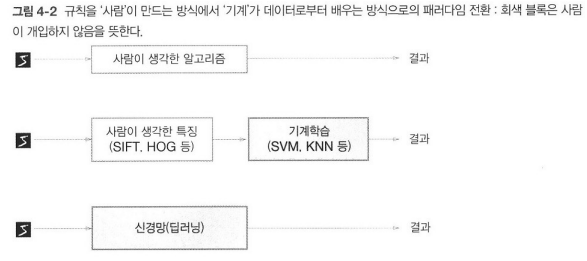   
- 지금까지 기계학습의 두 가지 접근법을 이야기함
- 이 두 방식 모두 그림으로 나타내면 위 그림의 중간과 같음
- 반면 신경망(딥러닝) 방식은 그림의 아래처럼 사람이 개입하지 않는 블록 하나로 그려짐

- 그림과 같이 신경망은 이미지를 '있는 그대로' 학습함
- 두 번째 접근 방식(특징과 기계학습 방식)에서는 특징을 사람이 설계했지만, 신경망은 이미지에 포함된 중요한 특징까지도 '기계'가 스스로 학습할 것

> 딥러닝을 **종단간 기계학습(end-to-end machine learning)**이라고도 함   
> 여기서 종단간은 '처음부터 끝까지'라는 의미로, 데이터(입력)에서 목표한 결과(출력)를 사람의 개입 없이 얻는다는 뜻을 담고 있음

신경망의 이점은 모든 문제를 같은 맥락에서 풀 수 있다는 점에 있음   
- 예를 들어 '5'를 인식하는 문제든,'개'를 인식하는 문제든, 아니면 '사람의 얼굴'을 인식하는 문제든
- 세부사항과 관계없이 신경망은 주어진 데이터를 온전히 학습하고, 주어진 문제의 패턴을 발견하려 시도함
- 즉, 신경망은 모든 문제를 주어진 데이터 그래로를 입력 데이터로 활용해 'end-to-end'로 학습할 수 있음

### 훈련 데이터와 시험 데이터

기계학습 문제는 데이터를 훈련 데이터(training data)와 시험 데이터(test data)로 나눠 학습과 실험을 수행하는 것이 일반적
1. 우선 훈련 데이터만 사용하여 학습하면서 최적의 매개변수를 찾음
2. 그런 다음 시험 데이터를 사용하여 앞서 훈련한 모델의 실력을 평가함

훈련 데이터와 시험 데이터를 나누는 이유: 우리가 원하는 것은 범용적으로 사용할 수 있는 모델이기 때문   
이 범용 능력을 제대로 평가하기 위해 훈련 데이터와 시험 데이터를 분리하는 것

범용 능력: 아직 보지 못한 데이터(훈련 데이터에 포함되지 않는 데이터)로도 문제를 올바르게 풀어내는 능력   
이 범용 능력을 획득하는 것이 기계학습의 최종 목표
- 예를 들어 손글씨 숫자 인식의 최종 결과는 엽서에서 우편 번호를 자동으로 판독하는 시스템에 쓰일 수 있음
- 그렇다면 손글씨 숫자 인식은 '누군가'가 쓴 글자를 인식하는 능력이 높지 않으면 안됨
- 그 누군가는 '특정인의 특정 글자'가 아니라 '임의의 사람의 글자'임
- 만약 수중에 있는 훈련 데이터만 잘 판별한다면 그 데이터에 포함된 사람의 글씨체만 학습했을 가능성이 큼

그래서 데이터셋 하나로만 매개변수의 학습과 평가를 수행하면 올바른 평가가 될 수 없음   
수중의 데이터셋은 제대로 맞히더라도 다른 데이터셋에는 엉망일 수 있음

한 데이터셋에만 지나치게 최적화된 상태를 **오버피팅(overfitting)**이라고 함   
오버피팅 피하기는 기계학습의 중요한 과제기도 함

## 손실 함수

사람들에게 "지금 얼마나 행복하나요?"라고 물으면 "아주 행복하죠"나 "그리 행복한 거 같지 않아요"라는 막연한 답이 돌아오는 게 일반적   
그 가운데 누군가 "현재 내 행복 지수는 10.23입니다"라고 대답한다면 질문한 사람이 당황해버림   
하나의 지표를 가지고 행복을 수치적으로 판단했다는 것이기 때문에 - 그런 사람이 정말 있다면 그 사람은 자신의 '행복 지표'를 기준으로 인생을 살아가게 될지도 모름

신경망 학습에서도 이와 같은 일을 수행함   
- 신경망 학습에서는 현재의 상태를 '하나의 지표'로 표현함   
- 그리고 그 지표를 가장 좋게 만들어주는 가중치 매개변수의 값을 탐색하는 것
- '행복 지표'를 가진 사람이 그 지표를 근거로 '최적의 인생'을 탐색하듯, 신경망도 '하나의 지표'를 기준으로 최적의 매개변수 값을 탐색함

**신경망 학습에서 사용하는 지표는 손실 함수(loss function)라고 함**   
이 손실 함수는 임의의 함수를 사용할 수도 있지만 일반적으로는 **평균 제곱 오차와 교차 엔트로피 오차**를 사용함

> **손실 함수는 신경망 성능의 '나쁨'을 나타내는 지표**   
> 현재의 신경망이 훈련 데이터를 얼마나 잘 처리하지 '못'하느냐를 나타냄   
> '성능 나쁨'을 지표로 한다는 것이 부자연스러워 보이지만, 손실 함수에 마이너스만 곱하면 '얼마나 나쁘지 않나', 즉 '얼마나 좋으냐'라는 지표로 변함   
> 또, '나쁨을 최소로 하는 것'과 '좋음을 최대로 하는 것'은 결국 같은 것이니까, 성능의 '나쁨'과 '좋음'중 어느 쪽을 지표로 삼아도 본질적으로 수행하는 일은 다르지 않음

### 평균 제곱 오차

가장 많이 쓰이는 손실 함수는 평균 제곱 오차(mean squared error, MSE)

- 평균 제곱 오차의 수식   
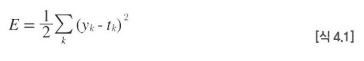   
- 여기서 y는 신경망의 출력(신경망이 추정한 값). tk는 정답 레이블, k는 데이터의 차원 수를 나타냄   
- 예를 들어 "손글씨 숫자 인식에서 yk와 tk는 다음과 같은 원소 10개짜리 데이터   
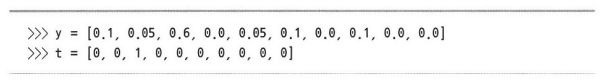   \
- 이 배열들의 원소는 첫 번째 인덱스부터 순서대로 숫자 '0', '1', '2', ...일 때의 값
- 여기서 신경망의 출력 y는 소프트맥스 함수의 출력   
- 소프트맥스 함수의 출력은 확률로 해석할 수 있으므로, 이 예에서는 이미지가 '0'일 확률은 0.1 '1'일 확률은 0.05, '2'일 확률은 0.6   
- 정답 레이블인 t는 정답을 가리키는 위치의 원소는 1로, 그 외에는 0으로 표기함 - 여기서는 숫자 '2'에 해당하는 원소의 값이 1이므로 정답이 '2'
- 이처럼 **한 원소만 1로 하고 그 외는 0으로 나타내는 표기법을 원-핫 인코딩**이라 함
- 평균 제곱 오차는 위 식과 같이 각 원소의 출력(추정 값)과 정답 레이블(참 값)의 차(yk - tk)를 제곱한 후, 그 총합을 구함

평균 제곱 오차를 파이썬으로 구현

In [57]:
import numpy as np

def mean_squared_error(y, t):
    return 0.5 * np.sum((y-t)**2)

- 여기에서 인수 y와 t는 넘파이 배열
- 식을 그대로 구현한 것

그러면 함수를 실제로 사용해보기

In [58]:
# 정답은 '2'
t = [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]

# 예1: '2'일 확률이 가장 높다고 추정함 (0.6)
y = [0.1, 0.05, 0.6, 0.0, 0.05, 0.1, 0.0, 0.1, 0.0, 0.0]
print(mean_squared_error(np.array(y), np.array(t)))

# 예2: '7'일 확률이 가장 높다고 추정함 (0.6)
y = [0.1, 0.05, 0.1, 0.0, 0.05, 0.1, 0.0, 0.6, 0.0, 0.0]
print(mean_squared_error(np.array(y), np.array(t)))

0.09750000000000003
0.5975


- 첫 번째의 예는 정답이 '2'고 신경망의 출력도 '2'에서 가장 높은 경우
- 두 번째의 예는 정답은 똑같이 '2'지만, 신경망의 출력은 '7'에서 가장 높음

이 실험의 결과로 첫 번째 예의 손실 함수 쪽 출력이 작으며 정답 레이블과의 오차도 작은 것을 알 수 있음   
즉, 평균 제곱 오차를 기준으로는 첫 번째 추정 결과가 (오차가 더 작으니) 정답에 더 가까울 것으로 판단할 수 있음

### 교차 엔트로피 오차

또 다른 손실 함수로서 교차 엔트로피 오차(cross entropy error, CEE)도 자주 이용함   

- 교차 엔트로피 오차의 수식   
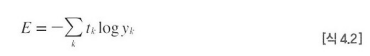   
- 여기에서 log는 및이 e인 자연로그
- yk는 신경망의 출력, tk는 정답 레이블
- 또 tk는 정답에 해당하는 인덱스의 원소만 1이고 나머지는 0 (원-핫 인코딩)
- 그래서 위 식은 실질적으로 정답일 때의 추정 (tk가 1일 때의 yk)의 자연로그를 계산하는 식이 됨
    - 예를 들어 정답 레이블은 '2'가 정답이라 하고 이때의 신경망 출력이 0.6이라면 교차 엔트로피 오차는 -log0.6 = 0.51이 됨
    - 또한, 같은 조건에서 신경망 출력이 0.1이라면 -log0.1 = 2.30이 됨

즉, 교차 엔트로피 오차는 정답일 때의 출력이 전체 값을 정하게 됨


- 자연로그의 그래프   
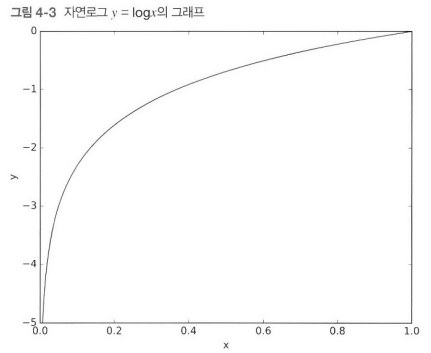   
- 이 그림에서 보듯이 x가 1일 때 y는 0이 되고 x가 0에 가까워질수록 y의 값은 점점 작아짐   
- 위에 식도 마찬가지로 정답에 해당하는 출력이 커질수록 0에 다가가다가, 그 출력이 1일 때 0이 됨
- 반대로 정답일 때의 출력이 작아질수록 오차는 커짐


교차 엔트로피 오차 구현하기

In [59]:
def cross_entropy_error(y, t):
    delta = 1e-7
    return -np.sum(t * np.log(y + delta))

- 여기에서 y와 t는 넘파이 배열
- 그런데 코드 마지막을 보면 np.log를 계산할 때 아주 작은 값인 delta를 더함   
- 이는 np.log() 함수에 0을 입력하면 마이너스 무한대를 뜻하는 -inf가 되어 더 이상 계산을 진행할 수 없게 되기 때문   
- 아주 작은 값을 더해서 절대 0이 되지 않도록, 즉 마이너스 무한대가 발생하지 않도록 한 것   

cross_entropy_error(y,t) 함수를 써서 간단한 계산 해보기 (정답은 똑같이 '2')

In [60]:
t = [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
y = [0.1, 0.05, 0.6, 0.0, 0.05, 0.1, 0.0, 0.1, 0.0, 0.0]
print(cross_entropy_error(np.array(y), np.array(t)))

y = [0.1, 0.05, 0.1, 0.0, 0.05, 0.1, 0.0, 0.6, 0.0, 0.0]
print(cross_entropy_error(np.array(y), np.array(t)))

0.510825457099338
2.302584092994546


- 첫 번째 예는 정답일 때의 출력이 0.6인 경우로, 이때의 교차 엔트로피 오차는 약 0.51
- 그 다음은 정답일 때의 출력이 (더 낮은) 0.1인 경우로, 이때의 교차 엔트로피 오차는 무려 2.3

즉, 결과(오차 값)가 더 작은 첫 번째 추정이 정답일 가능성이 높다고 판단한 것으로, 앞서 평균 제곱 오차의 판단과 일치함

### 미니배치 학습

기계학습 문제는 훈련 데이터를 사용해 학습함   
더 구체적으로 말하면 훈련 데이터에 대한 손실 함수의 값을 구하고, 그 값을 최대한 줄여주는 매개변수 찾아냄   
이렇게 하려면 모든 훈련 데이터를 대상으로 손실 함수 값을 구해야 함   
즉, 훈련 데이커가 100개 있으면 그로부터 계산한 100개의 손실 함수 값들의 합을 지표로 삼는 것

지금까지는 데이터 하나에 대한 손실 함수만 생각해왔으니, 이제 훈련 데이터 모두에 대한 손실 함수의 합을 구하는 방법을 알아봄   
- 예를 들어 교차 엔트로피 오차는 아래 식과 같이 됨
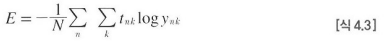
- 이때 데이터가 N개라면 tnk는 n번째 데이터의 k번째 값을 의미함 (ynk는 신경망의 출력, tnk는 정답 레이블)
- 수식이 좀 복잡해 보이지만 데이터 하나에 대한 손실 함수인 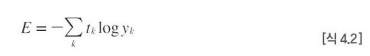를 단순히 N개의 데이터로 확장한 것
- 다만, 마지막에 N으로 나누어 정규화하고 있음
- N으로 나눔으로써 '평균 손실 함수'를 구하는 것
- 이렇게 평균을 구해 사용하면 훈련 데이터 개수와 관계없이 언제든 통일된 지표를 얻을 수 있음
    - 예를 들어 훈련 데이터가 1,000개든 10,000개든 상관없이 평균 손실 함수를 구할 수 있음


그런데 MNIST 데이터셋은 훈련 데이터가 60,000개였음   
그래서 모든 데이터를 대상으로 손실 함수의 합을 구하려면 시간이 좀 걸림   
더 나아가 빅데이터 수준이 되면 그 수는 수백만에서 수천만도 넘는 거대한 값이 되기도 함   
이 많은 데이터를 대상으로 일일이 손실 함수를 계산하는 것은 현실적이지 않음   
이런 경우 데이터 일부를 추려 전체의 '근사치'로 이용할 수 있음   
신경망 학습에서도 훈련 데이터로부터 일부만 골라 학습을 수행함   

이 일부를 **미니배치(mini-batch)**라고 함 - 가령 60,000장의 훈련 데이터 중에서 100장을 무작위로 뽑아 그 100장만을 사용하여 학습하는 것   
이러한 학습 방법을 **미니배치 학습**이라고 함   

미니배치 학습을 구현하는, 즉 훈련 데이터에서 지정한 수의 데이터를 무작위로 골라내는 코드를 작성하기 (MINST 데이터셋을 읽어오는 코드)

In [61]:
import sys, os
sys.path.append(os.pardir)
import numpy as np
from dataset.mnist import load_mnist

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

print(x_train.shape)
print(t_train.shape)

(60000, 784)
(60000, 10)


- load_mnist 함수는 MNIST 데이터셋을 읽어오는 함수
    - 이 함수는 datasel/mnist.py 파일에 있음
    - 이 함수는 훈련 데이터와 시험 데이터를 읽음
    - 호출할 때 one_hot_label=True로 지정하여 원-핫 인코딩으로, 즉 정답 위치의 원소만 1이고 나머지가 0인 배열을 얻을 수 있음

MNIST 데이터를 읽은 결과, 훈련 데이터는 60,000개고, 입력 데이터는 784열(원래는 28X28)인 이미지 데이터임을 알 수 있음   
또, 정답 레이블은 10줄짜리 데이터   
- 그래서 앞의 x_train, t_train의 모습은 각각 (60000, 784)와 (60000, 10)이 됨

그러면 이 훈련 데이터에서 무작위로 10장만 빼내는 방법은?   
넘파이의 np.random.choice() 함수를 쓰면 해결할 수 있음

In [62]:
train_size = x_train.shape[0]
batch_size = 10
batch_mask = np.random.choice(train_size, batch_size)
x_batch = x_train[batch_mask]
t_batch = t_train[batch_mask]

- np.random.choice()로는 지정한 범위의 수 중에서 무작위로 원하는 개수만 꺼낼 수 있음
    np.random.choice(60000, 10)은 0 이상 60000 미만의 수 중에서 무작위로 10개를 골라냄

다음은 실제로 돌려본 모습   
이 함수가 출려한 배열을 미니배치로 뽑아낼 데이터의 인덱스로 사용하면 됨

In [63]:
np.random.choice(60000, 10)

array([40087, 15239, 48918, 22775, 50103, 47013, 49468, 13799,  2182,
        8574], dtype=int32)

이제 무작위로 선택한 이 인덱스를 사용해 미니배치를 뽑아내기만 하면 됨   

손실 함수도 이 미니배치로 계산함

> 텔레비전 시청률도 모든 세대의 텔레비전이 아니라 선택된 일부 가구의 텔레비전만을 대상으로 구함   
> 예를 들어 경기 지방에서 무작위로 선정한 1,000가구를 대상으로 시청률을 계측한 다음, 경기 지방 전체의 시청률로 근사하는 것   
> 그 1,000가구의 시청률이 전체 시청률과 정확히 일치하지는 않겠지만, 전체의 대략적인 값으로 사용할 수 있음   
> 이 시청률 이야기와 마찬가지로 미니배치의 손실 함수도 일부 표본 데이터로 전체를 비슷하게 계측함   
> 즉, 전체 훈련 데이터의 대표로서 무작위로 선택한 작은 덩어리(미니배치)를 사용하는 것

### (배치용) 교차 엔트로피 오차 구현하기

그럼, 미니배치 같은 배치 데이터를 지원하는 교차 엔트로피 오차를 구하는 방법은?   

전에 구현한 교차 엔트로피 오차(데이터를 하나씩 처리하는 구현)를 조금만 바꿔주면 됨   
여기에서는 데이터가 하나인 경우와 데이터가 배치로 묶여 입력될 경우 모두를 처리할 수 있도록 구현

In [64]:
def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)
    
    batch_size = y.shape[0]
    return -np.sum(t * np.log(y + 1e-7)) / batch_size

이 코드에서 y는 신경망의 출력, t는 정답 레이블   

y가 1차원이라면, 즉 데이터 하나당 교차 엔트로피 오차를 구하는 경우는 reshape 함수로 데이터의 형상을 바꿔줌   
그리고 배치의 크기로 나눠 정규화하고 이미지 1장당 평균의 교차 엔트로피 오차를 계산함

정답 레이블이 원-핫 인코딩이 아니라 '2'나 '7'등의 숫자 레이블로 주어졌을 때의 교차 엔트로피 오차는 다음과 같이 구현할 수 있음

In [65]:
def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)
    
    batch_size = y.shape[0]
    return -np.sum(np.log(y[np.arange(batch_size), t] + 1e-7)) / batch_size

- 이 구현에서는 원-핫 인코딩일 때 t가 0인 원소는 교차 엔트로피의 오차도 0이므로, 그 계산은 무시해도 좋다는 것이 핵심   
- 다시 말하면 정답에 해당하는 신경망의 출력만으로 교차 엔트로피 오차를 계산할 수 있음
- 그래서 원-힛 인코딩 시 t * np.log(y) 였던 부분을 레이블 표현일 때는 np.log(y[np.arange(batch_size), t])로 구현함
- 미세한 값 1e-7은 동일한 역할


np.log(y[np.arange(batch_size), t])을 간단히 설명하면   
- np.arange(batch_size)는 0부터 batch_size - 1까지 배열을 생성함 - 즉 batch_size가 5이면 np.arange(batch_size)는 [0,1,2,3,4]라는 넘파이 배열을 생성함
- t에는 레이블이 [2, 7, 0, 9, 4]와 같이 저장되어 있으므로 y[np.arange(batch_size), t]는 각 데이터의 정답 레이블에 해당하는 신경망의 출력을 추출함
- (이 예에서는 y[np.arange(batch_size), t]는 [y[0,2], y[1,7], y[2,0], y[3,9], y[4,4]]인 넘파이 배열을 생성함)

### 왜 손실 함수를 설정하는가?

숫자 인식의 경우도 우리의 궁극적인 목적은 높은 '정확도'를 끌어내는 매개변수 값을 찾는 것   
그렇다면 '정확도'라는 지표를 놔두고 '손실 함수의 값'이라는 우회적인 방법을 택한 이유는?   

이 의문은 신경망 학습에서의 '미분'의 역할에 주목한다면 해결됨   
신경망 학습에서는 최적의 매개변수(가중치와 편향)를 탐색할 때 손실 함수의 값을 가능한 한 작게 하는 매개변수 값을 찾음   
이때 매개변수의 미분(정확히는 기울기)를 계산하고, 그 미분 값을 단서로 매개변수의 값을 서서히 갱신하는 과정을 반복함   

가령 여기에 가상의 신경망이 있고 그 신경망의 어느 한 가중치 매개변수에 주목한다고 하면   
이때 그 가중치 매개변수의 손실 함수의 미분이란 '가중치 매개변수의 값을 아주 조금 변화시켰을 때, 손실 함수가 어떻게 변하나'라는 의미   
만약 이 미분 값이 음수면 그 가중치 매개변수를 양의 방향으로 변화시켜 손실 함수의 값을 줄일 수 있음   
그러나 미분 값이 0이면 가중치 매개변수를 어느 쪽으로 움직여도 손실 함수의 값은 달라지지 않음   
그래서 그 가중치 매개변수의 갱신은 거기서 멈춤

정확도를 지표로 삼아서는 안 되는 이유는 미분 값이 대부분의 장소에서 0이 되어 매개변수를 갱신할 수 없기 때문

정리하면, *신경망을 학습할 때 정확도를 지표로 삼아서는 안 된다. 정확도를 지표로 하면 매개변수의 미분의 대부분의 장소에서 0이 되기 때문이다.*


정확도를 지표로 삼으면 매개변수의 미분이 대부분의 장소에서 0이 되는 이유는?   
- 구체적인 예를 들면, 한 신경망이 100장의 훈련 데이터 중 32장을 올바로 인식한다고 하면 정확도는 32%가 됨   
- 만약 정확도가 지표였다면 가중치 매개변수의 값을 조금 바꾼다고 해도 정확도는 그대로 32%일 것
- 즉, 매개변수를 약간만 조정해서는 정확도가 개선되니 않고 일정하게 유지됨
- 혹, 정확도가 개선된다 하더라도 그 값은 32.0123%와 같은 연속적인 변화보다는 33%나 34%처럼 불연속적인 띄엄띄엄한 값으로 바뀌어버림

한편 손실 함수를 지표로 삼는다면
- 현재의 손실 함수의 값은 0.92543... 같은 수치로 나타남
- 그리고 매개변수의 값이 조금 변하면 그에 반응하여 손실 함수의 값도 0.93432... 처럼 연속적으로 변화하는 것

**정확도는 매개변수의 미소한 변화에는 거의 반응을 보이지 않고, 반응이 있더라도 그 값이 불연속적으로 갑자기 변화함**   
이는 '계단 함수'를 활성화 함수로 사용하지 않는 이유와도 들어맞음

만약 활성화 함수로 계단 함수를 사용하면 지금까지 설명한 것과 같은 이유로 신경망 학습이 잘 이뤄지지 않음   
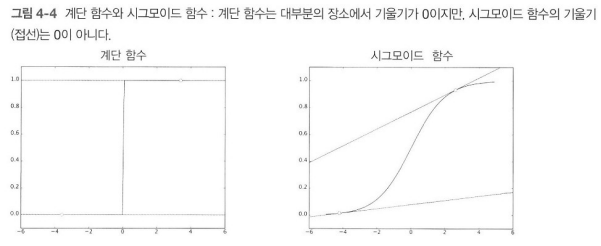   
- 계단 함수의 미분은 그림과 같이 대부분의 장소(0 이외의 곳)에서 0임
    - 그 결과, 계단 함수를 이용하면 손실 함수를 지표로 삼는 게 아무 의미가 없게 됨
    - 매개변수의 작은 변화가 주는 파장을 계단 함수가 말살하여 손실 함수의 값에는 아무 변화가 나타나지 않기 때문
- 계단 함수는 한순간만 변화를 일으키지만, 시그모이드 함수의 미분(접선)은 그림과 같이 출력(세로축의 값)이 연속적으로 변하고 곡선의 기울기도 연속적으로 변함
    - 즉, 시그모이드 함수의 미분은 어느 장소라도 0이 되지는 않음
    - 이는 신경망 학습에서 중요한 성질로, 기울기가 0이 되지 않는 덕분에 신경망이 올바르게 학습할 수 있는 것

## 수치 미분

경사법에서는 기울기(경사) 값을 기준으로 나아갈 방향을 정함   

기울기란 무엇인지, 또 어떤 성질이 있는지를 설명하기에 앞서, 이번 절에서는 '미분'부터 복습 예정

### 미분

마라톤 선수가 처음부터 10분에서 2km씩 달렸다고 가정하면   
이때의 속도는 간단히 2 / 10 = 0.2 [km/분]이라고 계산할 수 있음   
즉, 1분에 0.2km만큼의 속도(변화)로 뛰었다고 해석할 수 있음

이 마라톤 예에서는 '달린 거리'가 '시간'에 대해서 얼마나 변화했는가를 계산함   
다만 여기에서 10분에 2km를 뛰었다는 것은, 정확하게는 10분 동안의 '평균 속도'를 구한 것   
미분은 '특정 순간'의 변화량을 뜻함   
그래서 10분이라는 시간을 가능한 한 줄여(직전 1분에 달린 거리, 직전 1초에 달린 거리, 직전 0.1초에 달린 거리, ... 식으로 갈수록 간격을 줄여)    
한 순간의 변화량(어느 순간의 속도)을 얻는 것


이처럼 미분은 한순간의 변화량을 표시한 것   
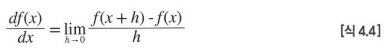   
- 위 식은 함수의 미분을 나타낸 식
- 좌변은 f(x)의 x에 대한 미분(x에 대한 f(x)의 변화량)을 나타내는 기호
- 결국, x의 '작은 변화'가 함수 f(x)를 얼마나 변화시키느냐를 의미
- 이때 시간의 작은 변화, 즉 시간을 뜻하는 h를 한없이 0에 가깝게 한다는 의미를 로 나타냄

식을 참고하여 함수를 미분하는 계산을 파이썬으로 구현하기   
위 식을 곧이곧대로 구현하려면 h에 작은 값을 대입해 다음과 같이 계산할 수 있음

In [66]:
# 나쁜 구현 예
def numerical_diff(f, x):
    h = 10e-50
    return (f(x + h) - f(x)) / h

- 함수의 이름은 수치 미분(numerical differentiation)에서 따온 numerical_diff(f, x)로 함
- 이 함수는 '함수 f와 '함수 f에 넘길 인수 x'라는 두 인수를 받음
- 얼핏 보면 문제가 없어 보이지만, 실제로는 개선해야 할 점이 2개 있음
    - 앞의 구현에서는 h에 가급적 작은 값을 대입하고 싶었기에(가능하다면 h를 0으로 무한히 가깝게 하고 싶으니) 10e-50이라는 작은 값을 이용함
    - 이 값은 0.00...1 형태에서 0이 50개라는 의미
    - 그러나 이 방식은 반올림 오차(rounding error) 문제를 일으킴
    - 반올림 오차는 작은 값(가령 소수점 8자리 이하)이 생략되어 최종 결과에 오차가 생기게 함

파이썬에서의 반올림 오차로는 다음의 예가 있음

In [67]:
np.float32(1e-50)

np.float32(0.0)

- 이와 같이 1e-50을 float32형(32비트 부동소수점)으로 나타내면 0.0이 되어, 올바로 표현할 수 없음
    - 너무 작은 값을 이용하면 컴퓨터로 계산하는 데 문제가 된다는 것 - 첫 번째 개선 포인트
    - 이 미세한 값 h로 10^(-4)을 이용 - 10^(-4) 정도의 값을 사용하면 좋은 결과를 얻는다고 알려져 있음

- 두 번째 개선은 함수 f의 차분과 관련한 것
    - 앞의 구현에서는 x + h와 x 사이의 함수 f의 차분을 계산하고 있지만, 애당초 이 계산에는 오차가 있다는 사실에 주의해야 함   
    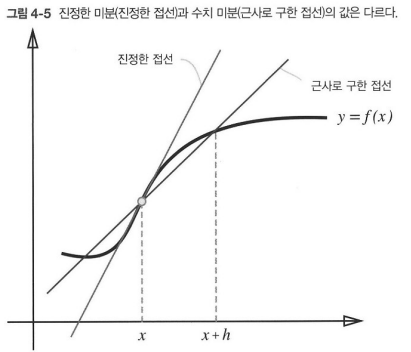   
    - 그림과 같이 '진정한 미분'은 x 위치의 함수의 기울기(이를 접선이라 함)에 해당하지만, 이번 구현에서의 미분은 (x + h)와 x 사이의 기울기에 해당함
    - 그래서 진정한 미분(진정한 접선)과 이번 구현의 값은 엄밀히는 일치하지 않음
    - 이 차이는 h를 무한히 0으로 좁히는 것이 불가능해 생기는 한계


그림과 같이 수치 미분에는 오차가 포함됨   
이 오차를 줄이기 위해 (x + h)와 (x - h)일 때의 함수 f의 차분을 계산하는 방법을 쓰기도 함   
이 차분은 x를 중심으로 그 전후의 차분을 계산한다는 의미에서 **중심 차분** 혹은 **중앙 차분**이라 함   
(한편, (x + h)와 x의 차분은 **전방 차분**이라 함)

그럼 두 개선점을 적용해 수치 미분을 다시 구현   
> 여기에서 하는 것처럼 아주 작은 차분으로 미분하는 것을 **수치 미분**이라 함   
> 한편, 수식을 전개해 미분하는 것은 **해석적**이라는 말을 이용하여 '해석적 해' 혹은 '해석적으로 미분하다'등으로 표현함   
> 가령, y=x^2의 미분은 해석적으로는 dy / dx = 2x로 풀어낼 수 있음   
> 그래서 x = 2일 때 y의 미분은 4가 됨   
> 해석적 미분은 오차를 포함하지 않는 '진정한 미분'값을 구해줌

In [68]:
def numerical_diff(f, x):
    h = 1e-4  # 0.0001
    return (f(x+h) - f(x-h)) / (2*h)

### 수치 미분의 예

앞 절의 수치 미분을 사용하여 간단한 함수를 미분해보기   

우선 다음과 같은 2차 함수   
   
위 식을 파이썬으로 구현하면

In [69]:
def function_1(x):
    return 0.01*x**2 + 0.1*x

이어서 이 함수를 그려보면

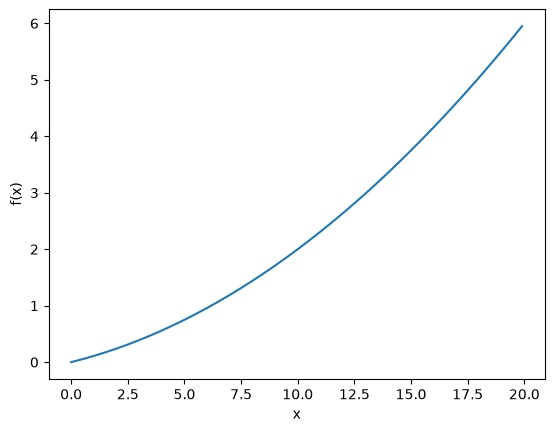

In [70]:
import numpy as np
import matplotlib.pylab as plt

x = np.arange(0.0, 20.0, 0.1)  # 0에서 20까지 0.1 간격의 배열 x를 만든다.
y = function_1(x)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.plot(x, y)
plt.show()

그럼 x=5일 때와 10일 때 이 함수의 미분을 계산하기

In [71]:
print(numerical_diff(function_1, 5))
print(numerical_diff(function_1, 10))

0.1999999999990898
0.2999999999986347


- 이렇게 계산한 미분 값이 x에 대한 f(x)의 변화량
- 즉, 함수의 기울기에 해당함
- 또한, 의 해석적 해는 
- 그래서 x가 5와 10일 때의 '진정한 미분'은 차례로 0.2와 0.3
- 앞의 수치 미분과 결과를 비교하면 그 오차가 매우 작음을 알 수 있음 - 실제로 거의 같은 값이라고 해도 될 만큼 작은 오차

이제 앞에서 구한 수치 미분 값을 기울기로 하는 직선을 그려보면   
- 함수의 접선에 해당하는 것을 확인할 수 있음

In [72]:
import sys
import os
import numpy as np
sys.path.append(os.pardir)
from codes.functions import softmax, cross_entropy_error
from codes.gradient import numerical_gradient


# 4.4.2 신경망에서의 기울기
class simpleNet:
    """docstring for simpleNet"""
    def __init__(self):
        self.W = np.random.randn(2, 3)  # 정규분포로 초기화

    def predict(self, x):
        return np.dot(x, self.W)

    def loss(self, x, t):
        z = self.predict(x)
        y = softmax(z)
        loss = cross_entropy_error(y, t)

        return loss


net = simpleNet()
print(net.W)  # 가중치 매개변수(랜덤)
x = np.array([0.6, 0.9])
p = net.predict(x)
print(p)
print(np.argmax(p))  # 최댓값의 인덱스

t = np.array([0, 0, 1])  # 정답 레이블
print(net.loss(x, t))


def f(W):
    return net.loss(x, t)


dW = numerical_gradient(f, net.W)
print(dW)

[[ 0.64956255 -1.25688453  0.14476891]
 [-0.84738097 -1.65144544  1.99000182]]
[-0.37290534 -2.24043161  1.87786298]
2
0.11474778174393203
[[ 0.05634049  0.00870491 -0.06504541]
 [ 0.08451074  0.01305737 -0.09756811]]


### 편미분

   
이어서 위 식의 함수를 살표보면   
인수들의 제곱 합을 계산하는 단순한 식이지만, 앞의 예와 달리 변수가 2개라는 점에 주의해야 함

이 식을 파이썬으로 구현하면

In [73]:
def function_2(x):
    return x[0]**2 + x[1]**2
    # 또는 return np.sum(x**2)

- 인수 x는 넘파이 배열이라고 가정함
- 이 코드는 넘파이 배열의 각 원소를 제곱하고 그 합을 구할 뿐인 간단한 구현 (또는 np.sum(x**2) 형태로 구현 가능)

이 함수를 그래프로 그려보면 3차원으로 그려짐   
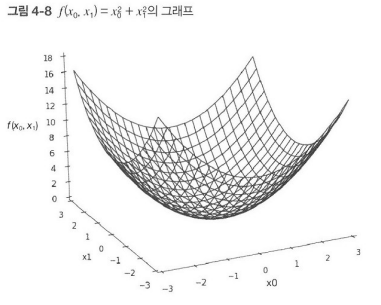   

- 그럼 위에 식을 미분해볼 때, 주의할 점은 이 식에는 변수가 2개라는 것
- 그래서 '어느 변수에 대한 미분이냐', 즉 x0와 x1 중 어느 변수에 대한 미분이냐를 구별해야 함
- 이와 같이 변수가 여럿인 함수에 대한 미분을 **편미분**이라 함
- 이 편미분을 수식으로는 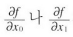처럼 씀


편미분은 어떻게 구하는지?

연습삼아 두 편미분 문제를 풀어봄

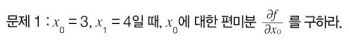

In [74]:
def function_tmp1(x0):
    return x0*x0 + 4.0**2.0

numerical_diff(function_tmp1, 3.0)

6.00000000000378

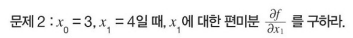

In [75]:
def function_tmp2(x1):
    return 3.0**2.0 + x1*x1

numerical_diff(function_tmp2, 4.0)

7.999999999999119

이 문제들은 변수가 하나인 함수를 정의하고, 그 함수를 미분하는 형태로 구현하여 풀었음
- 예를 들어 문제 1에서는 x1 = 4로 고정된 새로운 함수를 정의하고, 변수가 x0 하나뿐인 함수에 대해 수치 미분 함수를 적용함
- 이렇게 구한 문제 1의 결과는 6.00000000000378, 문제 2의 결과는 7.999999999999119
- 보다시피 해석적 미분의 결과와 거의 같음

이처럼 편미분은 변수가 하나인 미분과 마찬가지로 특정 장소의 기울기를 구함   
단, 여러 변수 중 목표 변수 하나에 초점을 맞추고 다른 변수는 값을 고정함   
앞의 예에서는 목표 변수를 제외한 나머지를 특정 값에 고정하기 위해서 새로운 함수를 정의함   
그리고 그 새로운 함수에 대해 그동안 사용한 수치 미분 함수를 적용하여 편미분을 구한 것

## 기울기

앞에 예에서는 x0와 x1의 편미분을 변수별로 따로 계산함

그럼 x0와 x1의 편미분을 동시에 계산하고 싶다면 어떻게 해야하는지?

가령 x0 = 3, x1 = 4일 때 (x0, x1) 양쪽의 편미분을 묶어서 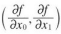을 계산한다고 생각하면   
이때 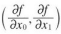처럼 모든 변수의 편미분을 벡터로 정리한 것을 **기울기(gradient)** 라고 함   

기울기는 예를 들어 다음과 같이 구현할 수 있음

In [76]:
def numerical_gradient(f, x):
    h = 1e-4  # 0.0001
    grad = np.zeros_like(x)  # x와 형상이 같은 배열을 생성

    for idx in range(x.size):
        tmp_val = x[idx]

        # f(x+h) 계산
        x[idx] = tmp_val + h
        fxh1 = f(x)

        # f(x-h) 계산
        x[idx] = tmp_val - h
        fxh2 = f(x)

        grad[idx] = (fxh1 - fxh2) / (2*h)
        x[idx] = tmp_val  # 값 복원

    return grad

numerical_gradient(f, x) 함수의 구현은 좀 복잡하게 보이지만, 동작 방식은 변수가 하나일 떄의 수치 미분과 거의 같음   
참고로, np.zeros_like(x)는 x와 형상이 같고 그 원소가 모두 0인 배열을 만듦   

numerical_gradient(f, x) 함수의 인수인 f는 함수이고 x는 넘파이 배열이므로 넘파이 배열 x의 각 원소에 대해서 수치 미분을 구함   

그러면 이 함수를 사용해서 실제로 기울기를 계산해보기   
여기에서는 세 점 (3, 4), (0, 2), (3, 0)에서의 기울기를 구해보기

In [78]:
print(numerical_gradient(function_2, np.array([3.0, 4.0])))
print(numerical_gradient(function_2, np.array([0.0, 2.0])))
print(numerical_gradient(function_2, np.array([3.0, 0.0])))

[6. 8.]
[0. 4.]
[6. 0.]


이처럼 (x0, x1)의 각 점에서의 기울기를 계산할 수 있음

- 앞의 예에서는 점(3, 4)의 기울기는 (6, 8), 점(0, 2)의 기울기는 (0, 4), 점 (3, 0)의 기울기는 (6, 0)이라는 결과를 얻었음

이 기울기가 의미하는 것은 그림으로 그려보면 이해할 수 있음   
다만, 여기에서는 기울기의 결과에 마이너스를 붙힌 벡터를 그려볼 것


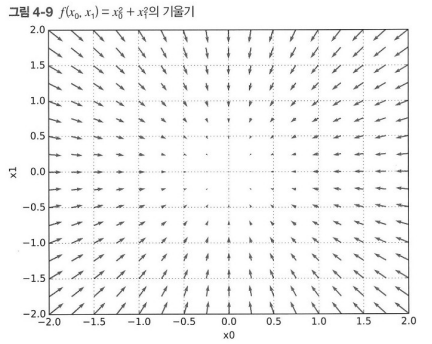
- 기울기 그림은 위 그림처럼 방향을 가진 벡터(화살표)로 그려짐
- 이 그림을 보면 기울기는 함수의 '가장 낮은 장소(최솟값)'를 가리키는 것 같아 보임
- 마치 나침반처럼 화살표들은 한 점을 향하고 있음
- 또 '가장 낮은 곳'에서 멀어질수록 화살표의 크기가 커짐을 알 수 있음

그림에서 기울기는 가장 낮은 장소를 가리키지만, 실제는 반드시 그렇다고는 할 수 없음   
사실 기울기는 각 지점에서 낮아지는 방향을 가리킴   
더 정확히 말하자면 **기울기가 가리키는 쪽은 각 장소에서 함수의 출력 값을 가장 크게 줄이는 방향** -- 매우 중요한 포인트!

### 경사법(경사 하강법)

기계학습 문제 대부분은 학습 단계에서 최적의 매개변수를 찾아냄   
신경망 역시 최적의 매개변수(가중치와 편향)를 학습 시에 찾아야 함   
여기에서 최적이란 손실 함수가 최솟값이 될 때의 매개변수 값   
그러나 일반적인 문제의 손실 함수는 매우 복잡함   
매개변수 공간이 광대하여 어디가 최솟값이 되는 곳인지를 짐작할 수 없음   
이런 상황에서 기울를 잘 이용해 함수의 최솟값(또는 가능한 한 작은 값)을 찾으려는 것이 경사법

여기에서 주의할 점은 각 지점에서 함수의 값을 낮추는 방안을 제시하는 지표가 기울기라는 것   
그러나 기울기가 가리키는 곳에 정말 함수의 최솟값이 있는지, 즉 그쪽이 정말로 나아갈 방향인지는 보장할 수 없음   
실제로 복잡한 함수에서는 기울기가 가리키는 방향에 최솟값이 없는 경우가 대부분임

> 함수가 극솟값, 최솟값, 또 **안장점(saddle point)** 이 되는 장소에서는 기울기가 0임   
> 극솟값은 국소적인 최솟값, 즉 한정된 범위에서의 최솟값인 점   
> 안장점은 어느 방향에서 보면 극댓값이고 다른 방향에서 보면 극솟값이 되는 점   
> 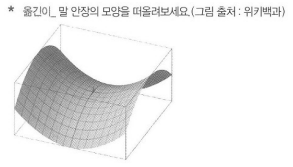   
> 경사법은 기울기가 0인 장소를 찾지만 그것이 반드시 최솟값이라고는 할 수 없음(극솟값이나 안장점일 가능성이 있음)   
> 또, 복잡하고 찌그러진 모양의 함수라면 (대부분) 평평한 곳으로 파고들면서 **고원(plateau, 플래토)** 이라 하는, 학습이 진행되지 않는 정체에 빠질 수 있음

기울어진 방향이 꼭 최솟값을 가리키는 것은 아니나, 그 방향으로 가야 함수의 값을 줄일 수 있음   
그래서 최솟값이 되는 장소를 찾는 문제(아니면 가능한 한 작은 값이 되는 장소를 찾는 문제)에서는 기울기 정보를 단서로 나아갈 방향을 정해야 함

여기서 경사법이 등장할 차례   
경사법은 현 위치에서 기울어진 방향으로 일정 거리만큼 이동함   
그런 다음 이동한 곳에서도 마찬가지로 기울기를 구하고, 또 그 기울어진 방향으로 나아가기를 반복함   
이렇게 해서 함수의 값을 점차 줄이는 것이 **경사법(gradient method)**   
경사법은 기계학습을 최적화하는 데 흔히 쓰는 방법   
특히 신경망 학습에는 경사법을 많이 사용함

> 경사법은 최솟값을 찾느냐, 최댓값을 찾느냐에 따라 이름이 다름   
> 최솟값은 **경사 하강법(gradient descent method)**, 최댓값은 **경사 상승법(gradient ascent method)**라고 함   
> 다만 손실 함수의 부호를 반전시키면 최솟값을 찾는 문제와 최댓값을 찾는 문제는 같은 것이니 하강이냐 상승이냐는 본질적으로는 중요하지 않음   
> 일반적으로 신경망(딥러닝) 분야에서의 경사법은 '경사 하강법'으로 등장할 때가 많음

그럼 경사법을 수식으로 나타내면   
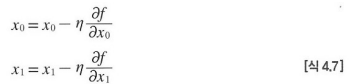   
- 식의 는 갱신하는 양을 나타냄   
- 이를 신경망 학습에서는 **학습률(learning rate)** 라고 함   
- 한 번의 학습으로 얼마만큼 학습해야 할지, 즉 매개변수 값을 얼마나 갱신하느냐를 정하는 것이 학습률

위 식은 1회에 해당하는 갱신이고, 이 단계를 반복함   
즉, 식처럼 변수의 값을 갱신하는 단계를 여러 번 반복하면서 서서히 함수의 값을 줄이는 것   
또, 여기에서는 변수가 2개인 경우를 보여줬지만, 변수의 수가 늘어도 같은 식(각 변수의 편미분 값)으로 갱신하게 됨

또한 학습률 값은 0.01이나 0.001 등 미리 특정 값으로 정해두어야 함   
일반적으로 이 값이 너무 크거나 작으면 '좋은 장소'를 찾아갈 수 없음   
신경망 학습에서는 보통 이 학습률 값을 변경하면서 올바르게 학습하고 있는지를 확인하면서 진행함

경사 하강법은 다음과 같이 간단하게 구현할 수 있음

In [79]:
def gradient_descent(f, init_x, lr=0.01, step_num=100):
    x = init_x

    for i in range(step_num):
        grad = numerical_gradient(f, x)
        x -= lr * grad
    return x

- 인수 f는 최적화하려는 함수, init_x는 초깃값, lr은 learning rate를 의미하는 학습률, step_num은 경사법에 따른 반복 횟수를 뜻함
- 함수의 기울기는 numerical_gradient(f, x)로 구하고, 그 기울기에 학습률을 곱한 값으로 갱신하는 처리를 step_num번 반복함

이 함수를 사용하면 함수의 극솟값을 구할 수 있고 잘하면 최솟값을 구할 수도 있음

연습삼아 다음 문제를 풀어보면   
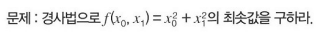

In [80]:
def function_2(x):
    return x[0]**2 + x[1]**2

init_x = np.array([-3.0, 4.0])
gradient_descent(function_2, init_x=init_x, lr=0.1, step_num=100)

array([-6.11110793e-10,  8.14814391e-10])

- 여기에서는 초깃값을 (-3.0, 4.0)으로 설정한 후 경사법을 사용해 최솟값 탐색을 시작함
- 최종 결과는 (-6.1e-10, 8.1e-10)으로, 거의 (0, 0)에 가까운 결과
- 실제로 진정한 최솟값은 (0, 0)이므로 경사법으로 거의 정확한 결과를 얻은 것

경사법을 사용한 이 갱신 과정을 그림으로 나타내면   
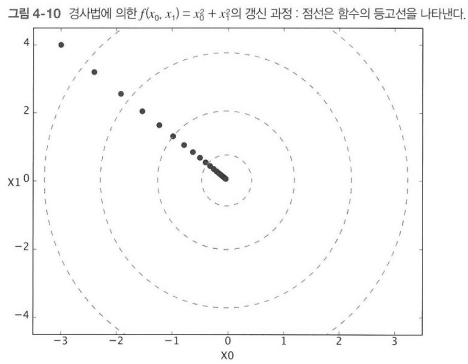   
- 값이 가장 낮은 장소인 원점에 점차 가까워지고 있음

여기서, 학습룰이 너무 크거나 작으면 좋은 결과를 얻을 수 없다고 했던 그 두 가지 경우를 실험해보기

In [81]:
# 학습률이 너무 큰 예: lr=10.0
init_x = np.array([-3.0, 4.0])
print(gradient_descent(function_2, init_x=init_x, lr=10.0, step_num=100))

# 학습률이 너무 작은 예: lr=1e-10
init_x = np.array([-3.0, 4.0])
print(gradient_descent(function_2, init_x=init_x, lr=1e-10, step_num=100))

[-2.58983747e+13 -1.29524862e+12]
[-2.99999994  3.99999992]


- 이 실험 결과와 같이 학습률이 너무 크면 큰 값으로 발산해버림
- 반대로 너무 작으면 거의 갱신되지 않은 채 끝나버림

> 학습률 같은 매개변수를 **하이퍼파라미터(hyper parameter, 초매개변수)** 라고 함   
> 이는 가중치와 편향 같은 신경망의 매개변수와는 성질이 다른 매개변수   
> 신경망의 가중치 매개변수는 훈련 데이터와 학습 알고리즘에 의해서 '자동'으로 획득되는 매개변수인 반면,   
> 학습률 같은 하이퍼파라미터는 사람이 직접 설정해야 하는 매개변수   
> 일반적으로는 이 하이퍼파라미터들은 여러 후보 값 중에서 시험을 통해 가장 잘 학습하는 값을 찾는 과정을 거쳐야 함

### 신경망에서의 기울기

신경망 학습에서도 기울기를 구해야 함   
여기서 말하는 기울기는 가중치 매개변수에 대한 손실 함수의 기울기   
- 예를 들어 형상이 2 X 3, 가중치가 W, 손실 함수가 L인 신경망을 생각해보면
- 이 경우 경사는 로 나타낼 수 있음
- 수식으로는 다음과 같음   
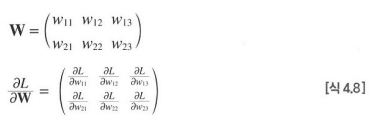   
- 의 각 원소는 각각의 원소에 관한 편미분
    - 예를 들어 1행 1번째 원소인 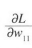은 w11을 조금 변경했을 때 손실 함수 L이 얼마나 변화하느냐를 나타냄
- 여기서 중요한 점은 의 형상이 W와 같다는 것
    - 실제로 위 식에서 W와 의 형상은 모두 2 X 3


그럼 간단한 신경망을 예로 들어 실제로 기울기를 구하는 코드를 구현해보기   
먼저 simpleNet 클래스를 살펴보면

In [84]:
import sys
import os
import numpy as np
sys.path.append(os.pardir)
from codes.functions import softmax, cross_entropy_error
from codes.gradient import numerical_gradient


class simpleNet:
    def __init__(self):
        self.W = np.random.randn(2, 3)  # 정규분포로 초기화

    def predict(self, x):
        return np.dot(x, self.W)

    def loss(self, x, t):
        z = self.predict(x)
        y = softmax(z)
        loss = cross_entropy_error(y, t)

        return loss

- 여기에서는 softmax와 cross_entropy_error 메서드를 사용함, 그리고 numerical_gradient 메서드도 이용함
- simpleNet 클래스는 형상이 2 X 3인 가중치 매개변수 하나를 인스턴스 변수로 가짐
- 메서드는 2개
    - 하나는 예측을 수행하는 predict(x)이고
    - 다른 하나는 손실 함수의 값을 구하는 loss(x, t)
    - 여기에서 x는 입력 데이터, t는 정답 레이블

simpleNet을 사용해 몇 가지 시험을 해보기

In [86]:
net = simpleNet()
print(net.W)  # 가중치 매개변수

x = np.array([0.6, 0.9])
p = net.predict(x)
print(p)

print(np.argmax(p))  # 최댓값의 인덱스

t = np.array([0, 0, 1])  # 정답 레이블
print(net.loss(x, t))

[[-0.79646976  0.27540494 -0.41427461]
 [-1.72039084 -0.72576382  0.30983217]]
[-2.02623361 -0.48794447  0.03028419]
2
0.5443415255766315


이어서 기울기를 구해보기

지금까지처럼 numerical_gradient(f, x)를 써서 구하면 됨   
(여기에서 정의한 f(W) 함수의 인수 W는 더미로 만든 것, numerical_gradient(f, x) 내부에서 f(x)를 실행하는데 그와의 일관성을 위해 f(W)를 정의한 것)

In [87]:
def f(W):
    return net.loss(x, t)

dW = numerical_gradient(f, net.W)
print(dW)

[[ 0.04452587  0.2073399  -0.25186577]
 [ 0.0667888   0.31100985 -0.37779865]]


- numerical_gradient(f, x)의 인수 f는 함수, x는 함수 f의 인수
- 그래서 여기에서는 net.W를 인수로 받아 손실 함수를 계산하는 새로운 함수 f를 정의함
- 그리고 이 새로 정의한 함수를 numerical_gradient(f, x)에 넘김

dW는 numerical_gradient(f, net.W)의 결과로, 그 형상은 2 X 3의 2차원 배열   
dW의 내용을 보면,   
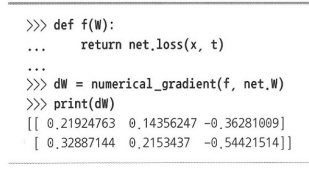   
- 예를 들어 의 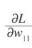은 대략 0.2
- 이는 w11을 h만큼 늘리면 손실 함수의 값은 0.2h만큼 증가한다는 의미
- 마찬가지로 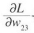은 대략 -0.5이니, 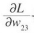을 h만큼 늘리면 손실 함수의 값은 0.5h만큼 감소하는 것   
- 그래서 손실 함수를 줄인다는 관점에서는 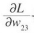은 양의 방향으로 갱신하고 w11은 음의 방향으로 갱신해야 함을 알 수 있음
- 또, 한 번에 갱신되는 양에는 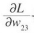이 w11보다 크게 기여한다는 사실도 알 수 있음


참고로 이 구현에서는 새로운 함수를 정의하는 데 "def f(x): ..." 문법을 썼는데, 피이썬에서는 간단한 함수라면 람다 기법을 쓰면 더 편함   
lambda를 쓰면 다음과 같이 구현 가능

In [88]:
f = lambda w: net.loss(x, t)
dW = numerical_gradient(f, net.W)

신경망의 기울기를 구한 다음에는 경사법에 따라 가중치 매개변수를 갱신하지만 하면 됨   

> 여기에서 사용한 numerical_gradient()는 가중치 매개변수 W가 다차원 배열을 처리할 수 있도록 앞의 구현에서 조금 수정함   
> 다차원 배열 처리 외에는 수정하지 않았으니 설명은 생략   

## 학습 알고리즘 구현하기

신경망 학습의 절차

전제
- 신경망에는 적응 가능한 가중치와 편향이 있고, 이 가중치와 편향을 훈련 데이터에 적응하도록 조정하는 과정을 '학습'이라 함
- 신경망 학습은 다음과 같이 4단계로 수행함

1단계 - 미니배치
- 훈련 데이터 중 일부를 무작위로 가져옴
- 이렇게 선별한 데이터를 미니배치라 하며, 그 미니배치의 손실 함수 값을 줄이는 것이 목표

2단계 - 기울기 산출
- 미니배치의 손실 함수 값을 줄이기 위해 각 가중치 매개변수의 기울기를 구함
- 기울기는 손실 함수의 값을 가장 작게 하는 방향을 제시함

3단계 - 매개변수 갱신
- 가중치 매개변수를 기울기 방향으로 아주 조금 갱신함

4단계 - 반복
- 1 ~ 3단계를 반복함

이것이 신경망 학습이 이뤄지는 순서   
이는 경사 하강법으로 매개변수를 갱신하는 방법이며, 이때 데이터를 미니배치로 무작위로 선정하기 때문에 **확률적 경사 하강법(stochastic gradient descent, SGD)** 라고 부름   
'확률적으로 무작위로 골라낸 데이터'에 대해 수행하는 경사 하강법이라는 의미   
대부분의 딥러닝 프레임워크는 확률적 경사 하강법의 영어 머리글자를 딴 **SGD** 라는 함수로 이 기능을 수현하고 있음

그럼 실제로 손글씨 숫자를 학습하는 신경망을 구현해보기   
여기에서는 2층 신경망(은닉층이 1개인 네트워크)을 대상으로 MNIST 데이터셋을 사용하여 학습을 수행함

### 2층 신경망 클래스 구현하기

처음에는 2층 신경망을 하나의 클래스로 구현하는 것부터 시작   

이 클래스의 이름은 TwoLayerNet

In [89]:
import sys, os
sys.path.append(os.pardir)
from codes.functions import *
from codes.gradient import numerical_gradient

class TwoLayerNet:
    def __init__(self, input_size, hidden_size, output_size, weight_init_std=0.01):
        # 가중치 초기화
        self.params = {}
        self.params['W1'] = weight_init_std * np.random.randn(input_size, hidden_size)
        self.params['b1'] = np.zeros(hidden_size)
        self.params['W2'] = weight_init_std * np.random.randn(hidden_size, output_size)
        self.params['b2'] = np.zeros(output_size)

    def predict(self, x):
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']

        a1 = np.dot(x, W1) + b1
        z1 = sigmoid(a1)
        a2 = np.dot(z1, W2) + b2
        y = softmax(a2)

        return y
    
    # x: 입력 데이터, t: 정답 레이블
    def loss(self, x, t):
        y = self.predict(x)

        return cross_entropy_error(y, t)
    
    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        t = np.argmax(t, axis=1)

        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy
    
    # x: 입력 데이터, t: 정답 레이블
    def numerical_gradient(self, x, t):
        loss_W = lambda W: self.loss(x, t)

        grads = {}
        grads['W1'] = numerical_gradient(loss_W, self.params['W1'])
        grads['b1'] = numerical_gradient(loss_W, self.params['b1'])
        grads['W2'] = numerical_gradient(loss_W, self.params['W2'])
        grads['b2'] = numerical_gradient(loss_W, self.params['b2'])

        return grads

코드가 좀 길어졌지만 앞에서 다룬 신경망의 순전파 처리 구현과 공통되는 부분이 많아 새로운 내용은 딱히 없음   

우선 이 클래스가 사용하는 변수와 메서드를 정리   
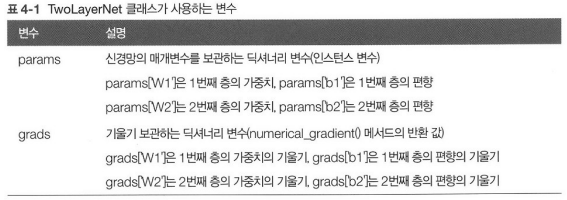   

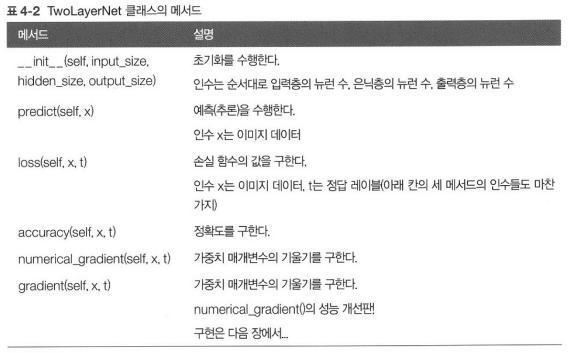   

TwoLayerNet 클래스는 딕셔너리인 params와 grads를 인스턴스 변수로 가짐   
params 변수에는 가중치 매개변수가 저장되는데
- 예를 들어 1번째 층의 가중치 매개변수는 params['W1'] 키에 넘파이 배열로 저장됨   
- 마찬가지로 1번째 층의 편향은 params['b1'] 키로 접근함

예시를 보면

In [90]:
net = TwoLayerNet(input_size=784, hidden_size=100, output_size=10)
print(net.params['W1'].shape)
print(net.params['b1'].shape)
print(net.params['W2'].shape)
print(net.params['b2'].shape)

(784, 100)
(100,)
(100, 10)
(10,)


이와 같이 params 변수에는 이 신경망에 필요한 매개변수가 모두 저장됨   
그리고 params 변수에 저장된 가중치 매개변수가 예측 처리(순방향 처리)에서 사용됨   

예측 처리는 다음과 같이 실행할 수 있음

In [91]:
x = np.random.rand(100, 784)  # 더미 입력 데이터(100장 분량)
y = net.predict(x)

grads 변수에는 params 변수에 대응하는 각 매개변수의 기울기가 저장됨   
- 예를 들어 다음과 같이 numerical_gradient() 메서드를 사용해 기울기를 계산하면 grads 변수에 기울기 정보가 저장됨

In [92]:
x = np.random.rand(100, 784)  # 더미 입력 데이터(100장 분량)
t = np.random.rand(100, 10)   # 더미 정답 레이블(100장 분량)

grads = net.numerical_gradient(x, t)  # 기울기 계산

print(grads['W1'].shape)
print(grads['b1'].shape)
print(grads['W2'].shape)
print(grads['b2'].shape)

(784, 100)
(100,)
(100, 10)
(10,)


이어서 TwoLayerNet의 메서드들을 살펴보면

- __init__(self, input_size, hidden_size, output_size) 메서드는 클래스를 초기화함 (초기화 메서드는 TwoLayerNet을 생성할 때 불리는 메서드)
    - 인수는 순서대로 입력층의 뉴런 수, 은닉층의 뉴런 수, 출력층의 뉴런 수
    - 예를 들어 손글씨 숫자 인식에서는 크기가 28 X 28인 입력 이미지가 총 784개이고 출력은 10개가 됨
    - 따라서 input_size=784, output_size=10으로 지정하고 은닉층의 개수인 hidden_size는 적당한 값을 설정함

이 초기화 메서드에서는 가중치 매개변수도 초기화함   
가중치 매개변수의 초깃값을 무엇으로 설정하냐가 신경망 학습의 성공을 좌우하기도 함   
가중치 매개변수 초기화에 대한 자세한 내용은 나중에 살펴봄 - 당장은 정규분포를 따르는 난수로, 편향은 0으로 초기화함

- predict(self, x)와 accuracy(self, x, t)의 구현은 앞에서 본 신경망의 추론 처리와 거의 같음

- loss(self, x, t)는 손실 함수의 값을 계산하는 메서드
    - 이 메서드는 predict()의 결과와 정답 레이블을 바탕으로 교차 엔트로피 오차를 구하도록 구현함

- numerical_gradient(self, x, t) 메서드는 각 매개변수의 기울기를 계산함
    - 수치 미분 방식으로 각 매개변수의 손실 함수에 대한 기울기를 계산함

- gradient(self, x, t)는 다음 장에서 구현할 메서드
    - 이 메서드는 오차역전파법을 사용하여 기울기를 효율적이고 빠르게 계산함

> numerical_gradient(self, x, t)는 수치 미분 방식으로 매개변수의 기울기를 계산함   
> 다음 장에서는 이 기울기 계산을 고속으로 수행하는 기법을 설명함 - 오차역전파법   
> 오차역전파법을 쓰면 수치 미분을 사용할 때와 거의 같은 결과를 훨씬 빠르게 얻을 수 있음   
> 오차역전파법으로 기울기를 구하는 gradient(self, x, t) 메서드는 다음 장에서 구현   
> 신경망 학습은 시간이 오래 걸리니, 시간을 절약하려면 numerical_gradient(self, x, t) 대신 gradient(self, x, t)를 쓰는 것이 좋음

### 미니배치 학습 구현하기

신경망 학습 구현에는 앞에서 설명한 미니배치 학습을 활용함

미니배치 학습이란 훈련 데이터 중 일부를 무작위로 꺼내고(미니배치), 그 미니배치에 대해서 경사법으로 매개변수를 갱신함

TwoLayerNet 클래스와 MNIST 데이터셋을 사용하여 학습을 수행해보기

In [96]:
import numpy as np
from dataset.mnist import load_mnist
from two_layer_net import TwoLayerNet

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

train_loss_list = []

# 하이퍼파라미터
# iters_num = 10000  # 반복 횟수
iters_num = 1  # 반복 횟수
train_size = x_train.shape[0]
batch_size = 100  # 미니배치 크기
learning_rate = 0.1

network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)

for i in range(iters_num):
    print(i)
    # 미니배치 획득
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    # 기울기 계산
    grad = network.numerical_gradient(x_batch, t_batch)
    # grad = network.gradient(x_batch, t_batch)  # 성능 개선판

    # 매개변수 갱신
    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key]

    # 학습 경과 기록
    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)

0


여기에서는 미니배치 크기를 100으로 함   
즉, 매번 60,000개의 훈련 데이터에서 임의로 100개의 데이터(이미지 데이터와 정답 레이블 데이터)를 추려냄   
그리고 그 100개의 미니배치를 대상으로 확률적 경사 하강법을 수행해 매개변수를 갱신함   
경사법에 의한 갱신 횟수(반복 횟수)를 10,000번으로 설정하고, 갱신할 때마다 훈련 데이터에 대한 손실 함수를 계산하고, 그 값을 배열에 추가함

이 손실 함수의 값이 변화하는 추이를 그래프로 나타내면   
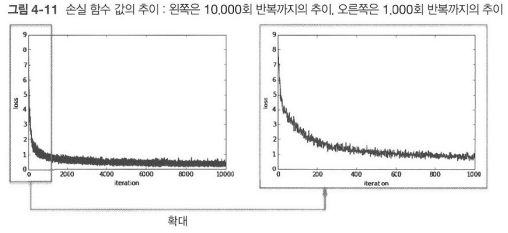   
- 그림을 보면 학습 횟수가 늘어가면서 손실 함수의 값이 줄어듦   
- 이는 학습이 잘 되고 있다는 뜻으로, 신경망의 가중치 매개변수가 서서히 데이터에 적응하고 있음을 의미함 - 신경망이 학습하고 있는 것
- 다시 말해 데이터를 반복해서 학습함으로써 최적 가중치 매개변수로 서서히 다가서고 있음

### 시험 데이터로 평가하기

위 그림의 결과에서 학습을 반복함으로써 손실 함수의 값이 서서히 내려가는 것을 확인할 수 있음   
이때의 손실 함수 값이란, 정확히는 '훈련 데이터의 미니배치에 대한 손실 함수'의 값   
훈련 데이터의 손실 함수 값이 작아지는 것은 신경망이 잘 학습하고 있다는 방증이지만, 이 결과만으로는 다른 데이터셋에도 비슷한 실력을 발휘할지는 확실하지 않음

신경망 학습에서는 훈련 데이터 외의 데이터를 올바르게 인식하는지를 확인해야 함   
다른 말로 '오버피팅'을 일으키지 않는지 확인해야 함   
- 오버피팅되었다는 것은, 예를 들어 훈련 데이터에 포함된 이미지만 제대로 구분하고, 그렇지 않은 이미지는 식별할 수 없다는 뜻

신경망 학습의 원래 목표는 범용적인 능력을 익히는 것   
범용 능력을 평가하려면 훈련 데이터에 포함되지 않은 데이터를 사용해 평가해봐야 함   
이를 위해 다음 구현에서는 학습 도중 정기적으로 훈련 데이터와 시험 데이터를 대상으로 정확도를 기록함   
여기에서는 1에폭별로 훈련 데이터와 시험 데이터에 대한 정확도를 기록함   

> **에폭(epoch)** 은 하나의 단위   
> 1에폭은 학습에서 훈련 데이터를 모두 소진했을 때의 횟수에 해당함   
> 예컨대 훈련 데이터 10,000개를 100개의 미니배치로 학습할 경우, 확률적 경사 하강법을 100회 반복하면 모든 훈련 데이터를 '소진'한 게 됨   
> 이 경우 100회가 1에폭이 됨


그럼 평가가 제대로 이뤄질 수 있도록 앞의 구현으로부터 조금만 수정하기   

In [98]:
import numpy as np
from dataset.mnist import load_mnist
from two_layer_net import TwoLayerNet

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

train_loss_list = []

####### 추가된 코드#######

train_acc_list = []
test_acc_list = []

# 1에폭당 반복 수
iter_per_epoch = max(train_size / batch_size, 1)

########################

# 하이퍼파라미터
# iters_num = 10000  # 반복 횟수
iters_num = 10  # 반복 횟수
train_size = x_train.shape[0]
batch_size = 100  # 미니배치 크기
learning_rate = 0.1

network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)

for i in range(iters_num):
    print(i)
    # 미니배치 획득
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    # 기울기 계산
    grad = network.numerical_gradient(x_batch, t_batch)
    # grad = network.gradient(x_batch, t_batch)  # 성능 개선판

    # 매개변수 갱신
    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key]

    # 학습 경과 기록
    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)

    ####### 추가된 코드#######

    # 1에폭당 정확도 계산
    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        print("train acc, test acc | " + str(train_acc) + ", " + str(test_acc))
    
    ########################

0
train acc, test acc | 0.09073333333333333, 0.0896
1
2
3
4
5
6
7
8
9


이 예에서는 1에폭마다 모든 훈련 데이터와 시험 데이터에 대한 정확도를 계산하고, 그 결과를 기록함   
정확도를 1에폭마다 계산하는 이유는 for문 안에서 매번 계산하기에는 시간이 오래 걸리고, 또 그렇게까지 자주 기록할 필요도 없기 때문   
더 큰 관점에서 그 추이를 알 수 있으면 충분함

앞에 코드로 얻은 결과를 그래프로 그려보면   
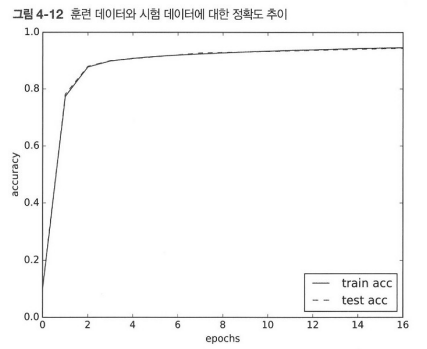   
- 그림에서는 훈련 데이터에 대한 정확도를 실선으로, 시험 데이터에 대한 정확도를 점선으로 그림 
- 에폭이 진행될수록(학습이 진행될수록) 훈련 데이터와 시험 데이터를 사용하고 평가한 정확도가 모두 좋아지고 있음   
- 또, 두 정확도에는 차이가 없음을 알 수 있음 (두 선이 거의 겹쳐 있음) 
- 다시 말해 이번 학습에서는 오버피팅이 일어나지 않음

# 정리

이번 장에서는 신경망 학습에 대해서 설명함   
가장 먼저 신경망이 학습을 수행할 수 있도록 손실 함수라는 '지표'를 도입함   
이 손실 함수를 기준으로 그 값이 가장 작아지는 가중치 매개변수 값을 찾아내는 것이 신경망 학습의 목표   
또, 가능한 한 작은 손실 함수의 값을 찾는 수법으로 경사   
경사법은 함수의 기울기를 이용하는 방법

## 이번 장에서 배운 내용

- 기계학습에서 사용하는 데이터셋은 훈련 데이터와 시험 데이터로 나눠 사용한다.
- 훈련 데이터로 학습한 모델의 범용 능력을 시험 데이터로 평가한다.
- 신경망 학습은 손실 함수를 지표로, 손실 함수의 값이 작아지는 방향으로 가중치 매개변수를 갱신한다.
- 가중치 매개변수를 갱신할 때는 가중치 매개변수의 기울기를 이용하고, 기울어진 방향으로 가중치의 값을 갱신하는 작업을 반복한다.
- 아주 작은 값을 주었을 때의 차분으로 미분하는 것을 수치 미분이라고 한다.
- 수치 미분을 이용해 가중치 매개변수의 기울기를 구할 수 있다.
- 수치 미분을 이용한 계산에는 시간이 걸리지만, 그 구현은 간단하다. 한편, 다음 장에서 구현하는 (다소 복잡한) 오차역전파법은 기울기를 고속으로 구할 수 있다.